# Consumer Credit Risk: PD, LGD and Simplified IFRS 9 ECL Model | LendingClub (Python)
**Simplified IFRS 9 illustration, not a production model.**

Pipeline: data & default definition -> WoE scorecard (PD) vs gradient boosting -> validation
(discrimination, calibration, stability) -> LGD / EAD -> Stage 1/2/3 ECL by grade -> base vs adverse -> Excel + docs.

## 0. Setup and configuration

In [25]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit, logit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.3})

# ---- CONFIG (edit these) ---------------------------------------------------
DATA_PATH = None   # None = auto-search. Or set the full path, e.g. r"C:\Users\you\Downloads\accepted_2007_to_2018Q4.csv"
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_END = "2014-12-31"       # train: issued on/before this date
TEST_START = "2015-01-01"      # out-of-time test window
TEST_END = "2016-12-31"        # stop before the heavily right-censored vintages

MAX_BINS, MIN_BIN_SHARE = 8, 0.02      # WoE binning
IV_MIN, IV_MAX, CORR_MAX = 0.02, 0.60, 0.80
MIN_POINT_SPREAD = 1.0         # a scorecard variable must move the score by at least this many points
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50   # scorecard scaling (good:bad odds)

RECALIBRATE_TO_TEST = True     # shift the scorecard intercept so mean PD = observed test default rate
ADV_ODDS_MULT = 1.5            # adverse scenario: PD odds x1.5
ADV_LGD_MULT = 1.15            # adverse scenario: LGD x1.15 (capped at 100%)
USE_LC_GRADE_AS_FEATURE = False  # LC grade/int_rate are LC's own model output -> excluded by default

## 1. Data: load, column check, default definition

In [26]:
def find_data_file(explicit=None):
    """Return the LendingClub file path: the explicit one, or the first match in common folders."""
    if explicit:
        p = Path(explicit).expanduser()
        if not p.exists():
            raise FileNotFoundError(f"DATA_PATH not found: {p}")
        return p
    patterns = ["accepted_2007_to_2018Q4.csv*", "accepted_2007_to_2018q4.csv*", "loan.csv*", "lending_club*.csv*"]
    roots = [Path.cwd(), Path.cwd().parent, Path.home() / "Downloads", Path.home() / "Desktop", Path.home() / "Documents"]
    for root in roots:
        if not root.exists():
            continue
        for pat in patterns:
            try:
                hits = [h for h in root.rglob(pat) if h.is_file() and h.suffix.lower() in {".csv", ".gz"}]
            except Exception:
                hits = []
            if hits:
                return sorted(hits, key=lambda h: h.stat().st_size, reverse=True)[0]
    raise FileNotFoundError(
        "LendingClub CSV not found. Download it from Kaggle (search 'Lending Club' -> accepted_2007_to_2018Q4.csv), "
        "unzip it, then either put it next to this notebook or set DATA_PATH to its full path.\n"
        f"Current folder: {Path.cwd()}")

DATA_PATH = find_data_file(DATA_PATH)
print("Using data file:", DATA_PATH)
header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

REQUIRED = ["loan_status", "issue_d", "recoveries", "total_rec_prncp", "out_prncp",
            "funded_amnt", "term", "grade"]
missing = [c for c in REQUIRED if c not in header]
print("Required columns present:", {c: (c in header) for c in REQUIRED})
if missing:
    raise ValueError(f"Missing required columns {missing}. This file can't support PD+LGD+EAD. "
                     "Use Kaggle 'Home Credit Default Risk' as a PD-only fallback.")

FEATURE_COLS = ["loan_amnt", "term", "annual_inc", "dti", "emp_length", "home_ownership",
                "verification_status", "purpose", "addr_state", "application_type",
                "fico_range_low", "fico_range_high", "earliest_cr_line", "revol_util", "revol_bal",
                "open_acc", "total_acc", "delinq_2yrs", "inq_last_6mths", "pub_rec",
                "mort_acc", "pub_rec_bankruptcies", "installment"]
EXTRA = ["int_rate", "sub_grade", "collection_recovery_fee", "last_pymnt_d"]
use = [c for c in dict.fromkeys(REQUIRED + FEATURE_COLS + EXTRA) if c in header]

raw = pd.read_csv(DATA_PATH, usecols=use, low_memory=False)
raw = raw[raw["loan_status"].notna()].copy()       # Kaggle files have trailer rows
print("Loaded:", raw.shape)
print(raw["loan_status"].value_counts())

Using data file: C:\Users\manis\Documents\LendingClub_ECL\accepted_2007_to_2018Q4.csv
Required columns present: {'loan_status': True, 'issue_d': True, 'recoveries': True, 'total_rec_prncp': True, 'out_prncp': True, 'funded_amnt': True, 'term': True, 'grade': True}
Loaded: (2260668, 34)
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [27]:
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace("%", "", regex=False), errors="coerce")

d = raw.copy()
d["issue_dt"] = pd.to_datetime(d["issue_d"], format="%b-%Y", errors="coerce")
d["term_m"] = to_num(d["term"].astype(str).str.extract(r"(\d+)")[0])
d["int_rate_n"] = to_num(d["int_rate"]) if "int_rate" in d else np.nan

# Default definition: Charged Off / Default = 1, Fully Paid = 0, everything else (in progress) dropped
GOOD = {"Fully Paid", "Does not meet the credit policy. Status:Fully Paid"}
BAD = {"Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off"}
d["y"] = np.where(d["loan_status"].isin(BAD), 1.0, np.where(d["loan_status"].isin(GOOD), 0.0, np.nan))

# ---- application-time feature engineering (no post-origination fields) ----
el = d["emp_length"].astype(str) if "emp_length" in d else pd.Series("nan", index=d.index)
d["emp_length_n"] = np.where(el.str.contains("<"), 0.0, to_num(el.str.extract(r"(\d+)")[0]))
if {"fico_range_low", "fico_range_high"} <= set(d.columns):
    d["fico_avg"] = (d["fico_range_low"] + d["fico_range_high"]) / 2
if "earliest_cr_line" in d:
    ecl_dt = pd.to_datetime(d["earliest_cr_line"], format="%b-%Y", errors="coerce")
    d["credit_hist_yrs"] = (d["issue_dt"] - ecl_dt).dt.days / 365.25
if "revol_util" in d:
    d["revol_util"] = to_num(d["revol_util"])
d["loan_to_income"] = (d["funded_amnt"] / d["annual_inc"]).clip(upper=5) if "annual_inc" in d else np.nan
if {"installment", "annual_inc"} <= set(d.columns):
    d["pti"] = (d["installment"] * 12 / d["annual_inc"]).clip(upper=2)
if "dti" in d:
    d["dti"] = d["dti"].clip(0, 100)

NUM_CANDIDATES = ["loan_amnt", "term_m", "annual_inc", "dti", "emp_length_n", "fico_avg", "credit_hist_yrs",
                  "revol_util", "revol_bal", "open_acc", "total_acc", "delinq_2yrs", "inq_last_6mths",
                  "pub_rec", "mort_acc", "pub_rec_bankruptcies", "loan_to_income", "pti"]
CAT_CANDIDATES = ["home_ownership", "verification_status", "purpose", "addr_state", "application_type"]
if USE_LC_GRADE_AS_FEATURE:
    NUM_CANDIDATES += ["int_rate_n"]
    CAT_CANDIDATES += ["grade", "sub_grade"]
NUM = [c for c in NUM_CANDIDATES if c in d.columns and d[c].notna().any()]
CAT = [c for c in CAT_CANDIDATES if c in d.columns and d[c].notna().any()]
FEATURES = NUM + CAT
print("Numeric features:", NUM)
print("Categorical features:", CAT)

Numeric features: ['loan_amnt', 'term_m', 'annual_inc', 'dti', 'emp_length_n', 'fico_avg', 'credit_hist_yrs', 'revol_util', 'revol_bal', 'open_acc', 'total_acc', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'mort_acc', 'pub_rec_bankruptcies', 'loan_to_income', 'pti']
Categorical features: ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'application_type']


## 2. Out-of-time split (by issue date)

Closed loans: 1,348,099 | train 453,809 (DR 17.03%) | test 668,651 (DR 21.54%)
Train window: Jun 2007 - Dec 2014; Test window: Jan 2015 - Dec 2016
           loans  default_rate
issue_dt                      
2007         603        0.2620
2008        2393        0.2073
2009        5281        0.1369
2010       12537        0.1401
2011       21721        0.1518
2012       53367        0.1620
2013      134804        0.1560
2014      223103        0.1845
2015      375546        0.2019
2016      293105        0.2329
2017      169321        0.2313
2018       56318        0.1576


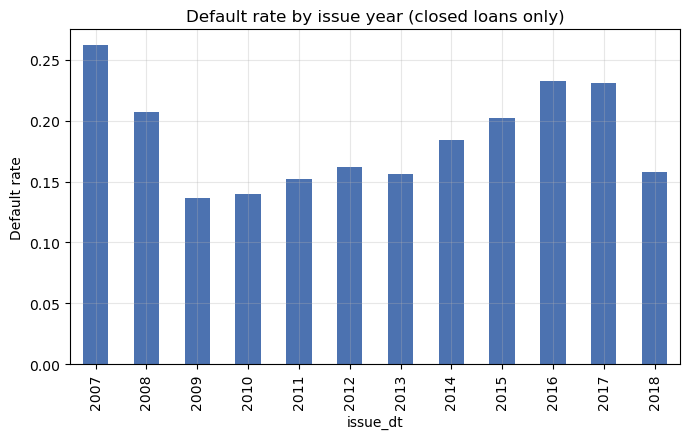


Missing share by issue year (variables with >5% missing in any year):
          emp_length_n  revol_util  mort_acc  pub_rec_bankruptcies
issue_dt                                                          
2007            0.0000      0.0530    1.0000                0.9670
2008            0.0000      0.0050    1.0000                0.3260
2009            0.0000      0.0030    1.0000                0.0010
2010            0.0280      0.0020    1.0000                0.0000
2011            0.0350      0.0000    1.0000                0.0000
2012            0.0360      0.0010    0.1400                0.0000
2013            0.0440      0.0010    0.0000                0.0000
2014            0.0520      0.0010    0.0000                0.0000
2015            0.0590      0.0000    0.0000                0.0000
2016            0.0640      0.0010    0.0000                0.0000
2017            0.0720      0.0010    0.0000                0.0000
2018            0.0880      0.0010    0.0000              

In [28]:
closed = d[d["y"].notna()].copy()
train = closed[closed["issue_dt"] <= TRAIN_END].copy()
test = closed[(closed["issue_dt"] >= TEST_START) & (closed["issue_dt"] <= TEST_END)].copy()
print(f"Closed loans: {len(closed):,} | train {len(train):,} (DR {train.y.mean():.2%}) | "
      f"test {len(test):,} (DR {test.y.mean():.2%})")
print(f"Train window: {train.issue_dt.min():%b %Y} - {train.issue_dt.max():%b %Y}; "
      f"Test window: {test.issue_dt.min():%b %Y} - {test.issue_dt.max():%b %Y}")

vint = closed.groupby(closed["issue_dt"].dt.year)["y"].agg(loans="size", default_rate="mean")
print(vint)
ax = vint["default_rate"].plot(kind="bar", color="#4C72B0")
ax.set_title("Default rate by issue year (closed loans only)")
ax.set_ylabel("Default rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_default_rate_by_vintage.png", dpi=150)
plt.show()

# Data-availability check: share of missing values by issue year (flags fields not populated for older loans)
miss = closed.groupby(closed["issue_dt"].dt.year)[NUM].apply(lambda g: g.isna().mean())
cols_miss = miss.columns[miss.max() > 0.05]
print("\nMissing share by issue year (variables with >5% missing in any year):")
print(miss[cols_miss].round(3).to_string() if len(cols_miss) else "none")
print("\nMissing share, train vs test:")
print(pd.DataFrame({"train": train[NUM].isna().mean(), "test": test[NUM].isna().mean()}).reindex(cols_miss).round(3).to_string()
      if len(cols_miss) else "none")

## 3. PD model A: WoE binning + logistic regression scorecard

In [29]:
class WoEBinner:
    """Quantile binning for numerics (missing = own bin), grouping rare categories, WoE = ln(%good/%bad)."""

    def __init__(self, num_cols, cat_cols, max_bins=8, min_share=0.02):
        self.num_cols, self.cat_cols = num_cols, cat_cols
        self.max_bins, self.min_share = max_bins, min_share
        self.edges, self.labels, self.keep, self.tables = {}, {}, {}, {}

    def _bin(self, col, x):
        if col in self.num_cols:
            idx = pd.cut(x, self.edges[col], labels=False, include_lowest=True)
            out = pd.Series("99: Missing", index=x.index, dtype=object)
            m = idx.notna()
            out[m] = np.array(self.labels[col], dtype=object)[idx[m].astype(int).values]
            return out
        out = x.astype(str).where(x.notna(), "Missing")
        return out.where(out.isin(self.keep[col]), "OTHER")

    def fit(self, X, y):
        for c in self.num_cols:
            cuts = np.unique(np.quantile(X[c].dropna(), np.linspace(0, 1, self.max_bins + 1)[1:-1]))
            e = np.r_[-np.inf, cuts, np.inf]
            self.edges[c] = e
            self.labels[c] = [f"{i:02d}: ({e[i]:.4g}, {e[i + 1]:.4g}]" for i in range(len(e) - 1)]
        for c in self.cat_cols:
            s = X[c].astype(str).where(X[c].notna(), "Missing")
            share = s.value_counts(normalize=True)
            self.keep[c] = set(share[share >= self.min_share].index)
        tg, tb = (y == 0).sum(), (y == 1).sum()
        iv_rows = []
        for c in self.num_cols + self.cat_cols:
            b = self._bin(c, X[c])
            ct = pd.crosstab(b, y).reindex(columns=[0.0, 1.0], fill_value=0)
            ct.columns = ["good", "bad"]
            ct["woe"] = np.log(((ct["good"] + 0.5) / tg) / ((ct["bad"] + 0.5) / tb))
            ct["iv_part"] = ((ct["good"] + 0.5) / tg - (ct["bad"] + 0.5) / tb) * ct["woe"]
            ct["n"] = ct["good"] + ct["bad"]
            ct["bad_rate"] = ct["bad"] / ct["n"]
            self.tables[c] = ct.sort_index()
            iv_rows.append((c, ct["iv_part"].sum()))
        self.iv = pd.DataFrame(iv_rows, columns=["feature", "IV"]).sort_values("IV", ascending=False)
        return self

    def transform(self, X, cols):
        out = {}
        for c in cols:
            woe = self.tables[c]["woe"].to_dict()
            out[c] = self._bin(c, X[c]).map(woe).fillna(0.0).values
        return pd.DataFrame(out, index=X.index)


binner = WoEBinner(NUM, CAT, MAX_BINS, MIN_BIN_SHARE).fit(train[FEATURES], train["y"])
print(binner.iv.to_string(index=False))

# feature selection: IV band, then drop highly correlated WoE features (keep higher IV)
cand = binner.iv[(binner.iv.IV >= IV_MIN) & (binner.iv.IV <= IV_MAX)]["feature"].tolist()
W_tr_all = binner.transform(train[FEATURES], cand)
selected = []
for c in cand:
    if all(abs(W_tr_all[c].corr(W_tr_all[s])) < CORR_MAX for s in selected):
        selected.append(c)
print("\nSelected scorecard features:", selected)

             feature     IV
              term_m 0.1954
      loan_to_income 0.1198
            fico_avg 0.1083
                 pti 0.0829
                 dti 0.0544
 verification_status 0.0416
          annual_inc 0.0362
          revol_util 0.0288
           loan_amnt 0.0288
      inq_last_6mths 0.0243
            mort_acc 0.0207
             purpose 0.0156
      home_ownership 0.0146
     credit_hist_yrs 0.0072
        emp_length_n 0.0061
          addr_state 0.0059
            open_acc 0.0043
           revol_bal 0.0033
             pub_rec 0.0021
pub_rec_bankruptcies 0.0019
         delinq_2yrs 0.0013
           total_acc 0.0008
    application_type 0.0000

Selected scorecard features: ['term_m', 'loan_to_income', 'fico_avg', 'dti', 'verification_status', 'annual_inc', 'revol_util', 'loan_amnt', 'inq_last_6mths', 'mort_acc']


In [30]:
# Fit, then enforce two sanity rules and refit until both hold:
#  (1) every WoE coefficient must be negative (WoE = ln good/bad, so higher WoE must mean lower default risk);
#  (2) every variable must move the score by at least MIN_POINT_SPREAD points (otherwise it is dead weight).
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
dropped = []
while True:
    W_tr = binner.transform(train[FEATURES], selected)
    lr = LogisticRegression(C=1.0, max_iter=2000).fit(W_tr, train["y"])
    coefs = pd.Series(lr.coef_[0], index=selected, name="coef")
    woe_rng = pd.Series({c: binner.tables[c]["woe"].max() - binner.tables[c]["woe"].min() for c in selected})
    spread = coefs.abs() * woe_rng * factor
    wrong_sign = coefs[coefs > 0]
    if len(wrong_sign):
        c = wrong_sign.idxmax()
        dropped.append((c, "wrong-sign coefficient"))
        selected.remove(c)
        continue
    weak = spread[spread < MIN_POINT_SPREAD]
    if len(weak):
        c = weak.idxmin()
        dropped.append((c, f"score spread only {weak.min():.1f} points"))
        selected.remove(c)
        continue
    break

W_te = binner.transform(test[FEATURES], selected)
print("Dropped after sign / materiality checks:", dropped if dropped else "none")
print("Final scorecard features:", selected)
print(pd.DataFrame({"coef": coefs, "score_spread_pts": spread}).round(3).to_string())
print("Intercept:", round(lr.intercept_[0], 4))

pd_sc_train = lr.predict_proba(W_tr)[:, 1]
pd_sc_test = lr.predict_proba(W_te)[:, 1]

# scorecard points table
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_feat = len(selected)
rows = []
for c in selected:
    for b, r in binner.tables[c].iterrows():
        pts = -(coefs[c] * r["woe"] + lr.intercept_[0] / n_feat) * factor + offset / n_feat
        rows.append({"feature": c, "bin": b, "n": int(r["n"]), "bad_rate": r["bad_rate"],
                     "woe": r["woe"], "points": round(pts, 1)})
scorecard_table = pd.DataFrame(rows)
print(scorecard_table.head(15).to_string(index=False))

def pd_to_score(p):
    return offset + factor * (-logit(np.clip(p, 1e-6, 1 - 1e-6)))

score_train, score_test = pd_to_score(pd_sc_train), pd_to_score(pd_sc_test)

Dropped after sign / materiality checks: [('loan_amnt', 'wrong-sign coefficient'), ('revol_util', 'score spread only 0.5 points')]
Final scorecard features: ['term_m', 'loan_to_income', 'fico_avg', 'dti', 'verification_status', 'annual_inc', 'inq_last_6mths', 'mort_acc']
                       coef  score_spread_pts
term_m              -0.9410           26.0090
loan_to_income      -0.4060           13.7060
fico_avg            -0.9040           29.2480
dti                 -0.4800           10.3030
verification_status -0.2370            3.1160
annual_inc          -0.7690           18.6640
inq_last_6mths      -1.0700           23.6190
mort_acc            -0.7260            8.2940
Intercept: -1.5861
       feature                   bin      n  bad_rate     woe  points
        term_m        00: (-inf, 36] 337996    0.1316  0.3032 74.8000
        term_m          01: (36, 60] 115813    0.2831 -0.6548 48.8000
loan_to_income   00: (-inf, 0.08861]  56749    0.1115  0.4919 72.4000
loan_to_income 

## 4. PD model B: gradient boosting (all candidate features)

GBM iterations used: 500


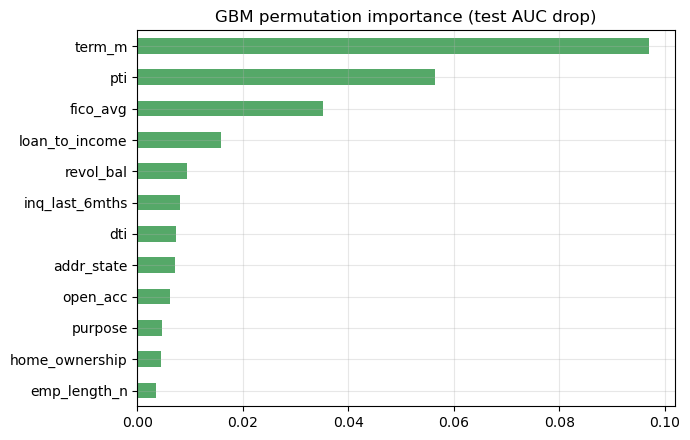

In [31]:
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)
if CAT:
    enc.fit(train[CAT].astype(str))

def gbm_matrix(df_):
    parts = [df_[NUM].values.astype(float)]
    if CAT:
        parts.append(enc.transform(df_[CAT].astype(str)))
    return np.hstack(parts)

cat_mask = [False] * len(NUM) + [True] * len(CAT)
gbm = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=500, max_depth=4, min_samples_leaf=200, l2_regularization=1.0,
    categorical_features=cat_mask if CAT else None, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=20, random_state=RANDOM_STATE)
gbm.fit(gbm_matrix(train), train["y"])
pd_gbm_train = gbm.predict_proba(gbm_matrix(train))[:, 1]
pd_gbm_test = gbm.predict_proba(gbm_matrix(test))[:, 1]
print("GBM iterations used:", gbm.n_iter_)

# permutation importance (test sample)
samp = test.sample(min(20000, len(test)), random_state=RANDOM_STATE)
pi = permutation_importance(gbm, gbm_matrix(samp), samp["y"], scoring="roc_auc", n_repeats=3,
                            random_state=RANDOM_STATE)
imp = pd.Series(pi.importances_mean, index=NUM + CAT).sort_values().tail(12)
imp.plot(kind="barh", color="#55A868", title="GBM permutation importance (test AUC drop)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_gbm_importance.png", dpi=150)
plt.show()

## 5. Validation: discrimination

                        AUC   Gini     KS  Brier
Scorecard (train)    0.6818 0.3636 0.2637 0.1325
Scorecard (OOT test) 0.6912 0.3824 0.2720 0.1579
GBM (train)          0.7215 0.4431 0.3222 0.1279
GBM (OOT test)       0.7141 0.4282 0.3073 0.1541


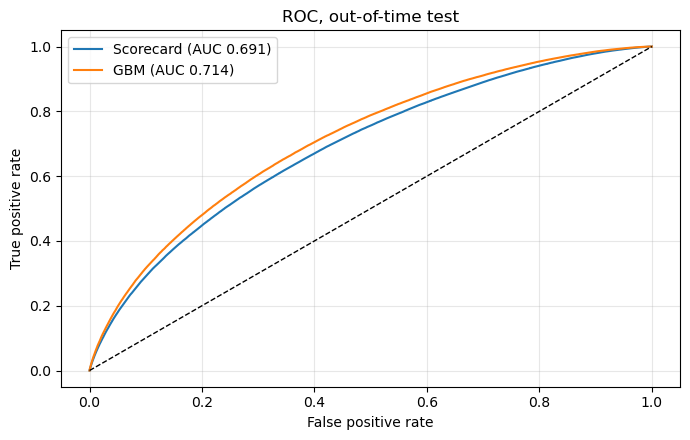

In [32]:
def ks_stat(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return float(np.max(tpr - fpr))

def discrimination(y, p):
    auc = roc_auc_score(y, p)
    return {"AUC": auc, "Gini": 2 * auc - 1, "KS": ks_stat(y, p), "Brier": brier_score_loss(y, p)}

disc = pd.DataFrame({
    "Scorecard (train)": discrimination(train.y, pd_sc_train),
    "Scorecard (OOT test)": discrimination(test.y, pd_sc_test),
    "GBM (train)": discrimination(train.y, pd_gbm_train),
    "GBM (OOT test)": discrimination(test.y, pd_gbm_test),
}).T
print(disc)

plt.figure()
for name, p in [("Scorecard", pd_sc_test), ("GBM", pd_gbm_test)]:
    f, t, _ = roc_curve(test.y, p)
    plt.plot(f, t, label=f"{name} (AUC {roc_auc_score(test.y, p):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC, out-of-time test")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_roc_oot.png", dpi=150)
plt.show()

## 6. Validation: calibration (decile table, reliability plot, slope & intercept)

Scorecard, OOT test deciles
decile  loans    defaults  avg_pd  obs_dr  obs_over_pred
     1  66866  3,958.0000  0.0542  0.0592         1.0926
     2  66865  6,855.0000  0.0824  0.1025         1.2447
     3  66865  8,889.0000  0.1026  0.1329         1.2962
     4  66865 10,300.0000  0.1206  0.1540         1.2775
     5  66865 11,943.0000  0.1385  0.1786         1.2894
     6  66865 13,773.0000  0.1577  0.2060         1.3065
     7  66864 15,593.0000  0.1801  0.2332         1.2948
     8  66866 18,300.0000  0.2102  0.2737         1.3020
     9  66865 22,612.0000  0.2610  0.3382         1.2959
    10  66865 31,833.0000  0.3743  0.4761         1.2718
           calibration_slope  calibration_intercept (CITL)  mean_pred_PD  observed_DR
Scorecard             1.1068                        0.3278        0.1681       0.2154
GBM                   1.0613                        0.3131        0.1711       0.2154

Slope < 1 = over-dispersed (too confident); intercept > 0 = PDs too low (under-predict

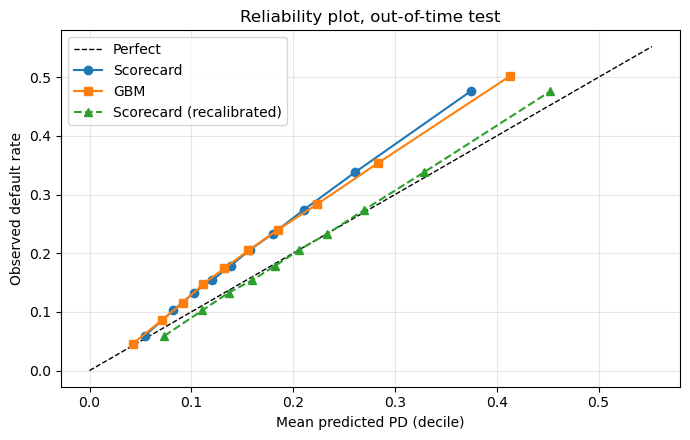

In [33]:
def decile_table(y, p, n=10):
    t = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(p)})
    t["decile"] = pd.qcut(t["p"].rank(method="first"), n, labels=range(1, n + 1))
    g = t.groupby("decile", observed=True).agg(loans=("y", "size"), defaults=("y", "sum"),
                                              avg_pd=("p", "mean"), obs_dr=("y", "mean"))
    g["obs_over_pred"] = g["obs_dr"] / g["avg_pd"]
    return g.reset_index()

def calibration_stats(y, p):
    z = logit(np.clip(p, 1e-6, 1 - 1e-6))
    slope = LogisticRegression(C=1e9, max_iter=1000).fit(z.reshape(-1, 1), y).coef_[0, 0]
    citl = brentq(lambda a: expit(z + a).mean() - np.mean(y), -5, 5)  # intercept with slope fixed at 1
    return {"calibration_slope": slope, "calibration_intercept (CITL)": citl,
            "mean_pred_PD": float(np.mean(p)), "observed_DR": float(np.mean(y))}

dec_sc, dec_gbm = decile_table(test.y, pd_sc_test), decile_table(test.y, pd_gbm_test)
print("Scorecard, OOT test deciles"); print(dec_sc.to_string(index=False))
cal = pd.DataFrame({"Scorecard": calibration_stats(test.y, pd_sc_test),
                    "GBM": calibration_stats(test.y, pd_gbm_test)}).T
print(cal)
print("\nSlope < 1 = over-dispersed (too confident); intercept > 0 = PDs too low (under-prediction).")

# optional intercept recalibration of the scorecard to the OOT default rate
shift = 0.0
if RECALIBRATE_TO_TEST:
    z_te = logit(np.clip(pd_sc_test, 1e-6, 1 - 1e-6))
    shift = brentq(lambda a: expit(z_te + a).mean() - test.y.mean(), -5, 5)
    print(f"Intercept shift applied to scorecard: {shift:+.4f}")
pd_sc_test_cal = expit(logit(np.clip(pd_sc_test, 1e-6, 1 - 1e-6)) + shift)
cal_after = calibration_stats(test.y, pd_sc_test_cal)
print("Scorecard after recalibration:", {k: round(v, 4) for k, v in cal_after.items()})

fig, ax = plt.subplots()
lim = max(dec_sc.avg_pd.max(), dec_sc.obs_dr.max(), dec_gbm.obs_dr.max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", lw=1, label="Perfect")
ax.plot(dec_sc.avg_pd, dec_sc.obs_dr, "o-", label="Scorecard")
ax.plot(dec_gbm.avg_pd, dec_gbm.obs_dr, "s-", label="GBM")
d_cal = decile_table(test.y, pd_sc_test_cal)
ax.plot(d_cal.avg_pd, d_cal.obs_dr, "^--", label="Scorecard (recalibrated)")
ax.set_xlabel("Mean predicted PD (decile)"); ax.set_ylabel("Observed default rate")
ax.set_title("Reliability plot, out-of-time test"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_reliability.png", dpi=150)
plt.show()

## 7. Validation: stability (PSI train vs test)

            variable    PSI              flag
            mort_acc 0.7982 Significant shift
 verification_status 0.0516            Stable
      inq_last_6mths 0.0484            Stable
                 dti 0.0447            Stable
          revol_util 0.0396            Stable
    application_type 0.0374            Stable
          addr_state 0.0368            Stable
             pub_rec 0.0290            Stable
             purpose 0.0270            Stable
pub_rec_bankruptcies 0.0213            Stable
            open_acc 0.0188            Stable
        emp_length_n 0.0140            Stable
     credit_hist_yrs 0.0120            Stable
            fico_avg 0.0076            Stable
      home_ownership 0.0075            Stable
                 pti 0.0072            Stable
          annual_inc 0.0071            Stable
         delinq_2yrs 0.0059            Stable
           revol_bal 0.0059            Stable
           loan_amnt 0.0045            Stable
              term_m 0.0037       

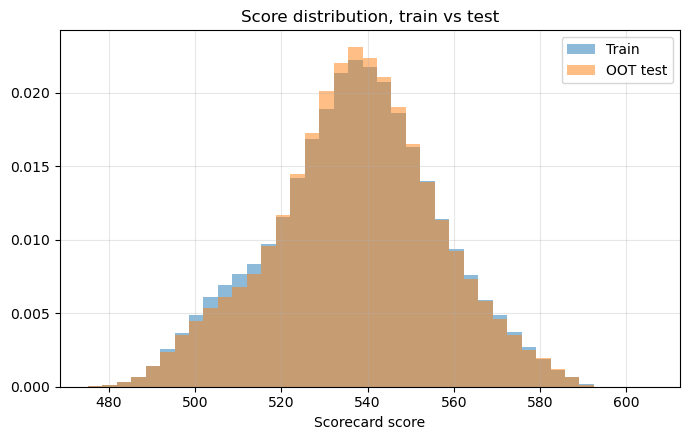

In [34]:
def _psi(e, a):
    e = np.maximum(e / e.sum(), 1e-4)
    a = np.maximum(a / a.sum(), 1e-4)
    return float(np.sum((a - e) * np.log(a / e)))

def psi_numeric(tr, te, bins=10):
    tr, te = pd.Series(tr), pd.Series(te)
    cuts = np.unique(np.nanquantile(tr.dropna(), np.linspace(0, 1, bins + 1)[1:-1]))
    edges = np.r_[-np.inf, cuts, np.inf]
    def cnt(x):
        idx = pd.cut(x, edges, labels=False, include_lowest=True).dropna().astype(int)
        return np.r_[np.bincount(idx, minlength=len(edges) - 1), x.isna().sum()].astype(float)
    return _psi(cnt(tr), cnt(te))

def psi_categorical(tr, te):
    a = pd.Series(tr).astype(str).value_counts()
    b = pd.Series(te).astype(str).value_counts()
    cats = a.index.union(b.index)
    return _psi(a.reindex(cats, fill_value=0).values.astype(float), b.reindex(cats, fill_value=0).values.astype(float))

def psi_flag(v):
    return "Stable" if v < 0.10 else ("Moderate shift" if v < 0.25 else "Significant shift")

psi_rows = [("SCORE (scorecard)", psi_numeric(score_train, score_test)),
            ("PD (GBM)", psi_numeric(pd_gbm_train, pd_gbm_test))]
for c in NUM:
    psi_rows.append((c, psi_numeric(train[c], test[c])))
for c in CAT:
    psi_rows.append((c, psi_categorical(train[c], test[c])))
psi_df = pd.DataFrame(psi_rows, columns=["variable", "PSI"])
psi_df["flag"] = psi_df["PSI"].map(psi_flag)
print(psi_df.sort_values("PSI", ascending=False).to_string(index=False))

plt.figure()
bins_ = np.linspace(min(score_train.min(), score_test.min()), max(score_train.max(), score_test.max()), 40)
plt.hist(score_train, bins=bins_, alpha=0.5, density=True, label="Train")
plt.hist(score_test, bins=bins_, alpha=0.5, density=True, label="OOT test")
plt.xlabel("Scorecard score"); plt.title("Score distribution, train vs test"); plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_score_psi.png", dpi=150)
plt.show()

## 8. Model choice: performance vs interpretability

In [35]:
auc_sc, auc_gbm = disc.loc["Scorecard (OOT test)", "AUC"], disc.loc["GBM (OOT test)", "AUC"]
gap = auc_gbm - auc_sc
print(f"OOT AUC  scorecard={auc_sc:.4f}  GBM={auc_gbm:.4f}  uplift={gap:+.4f}")
if gap < 0.01:
    CHOICE = "Scorecard"
    reason = ("GBM adds <1 AUC point out-of-time, which does not justify the loss of transparency, "
              "monotonic reason codes and easy validation/governance.")
else:
    CHOICE = "Scorecard (GBM as challenger)"
    reason = (f"GBM is {gap * 100:.1f} AUC points better; consider it as a challenger or add monotonic constraints and "
              "SHAP-based explanations before replacing the scorecard. The scorecard stays primary for transparency.")
print("Recommended primary model:", CHOICE, "->", reason)

OOT AUC  scorecard=0.6912  GBM=0.7141  uplift=+0.0229
Recommended primary model: Scorecard (GBM as challenger) -> GBM is 2.3 AUC points better; consider it as a challenger or add monotonic constraints and SHAP-based explanations before replacing the scorecard. The scorecard stays primary for transparency.


## 9. LGD and EAD (from defaulted loans)

out_prncp on defaulted loans (should be ~0): {'mean': 1.42, 'max': 28222.01}
Overall exposure-weighted LGD: 91.0%
grade    defaults   EAD_at_default      recoveries    LGD  EAD_pct_of_funded
    A 14,213.0000 114,955,165.8600  9,602,729.7455 0.9165             0.5892
    B 52,652.0000 455,004,480.9700 39,485,251.1025 0.9132             0.6382
    C 85,801.0000 883,900,255.8600 78,266,071.7684 0.9115             0.6991
    D 61,259.0000 723,757,062.5900 64,994,296.3066 0.9102             0.7394
    E 36,196.0000 511,981,712.8400 48,264,835.0248 0.9057             0.7817
    F 14,585.0000 234,400,635.7300 22,764,804.6142 0.9029             0.8232
    G  4,632.0000  80,813,690.4900  7,668,263.2345 0.9051             0.8568


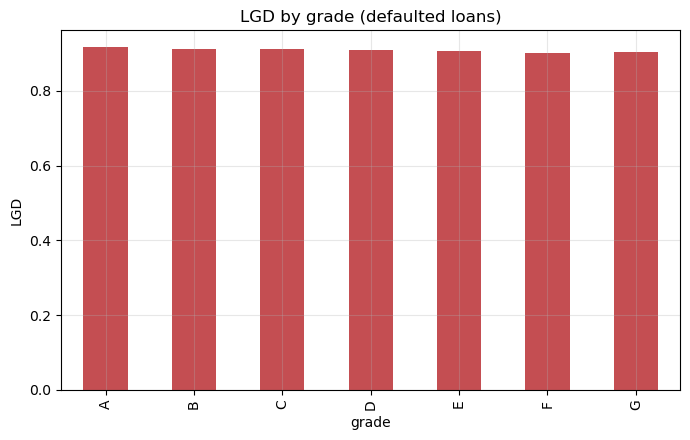

In [36]:
# NOTE: out_prncp is ~0 for charged-off loans (balance has been written off), so EAD at default is
# approximated as funded_amnt - total_rec_prncp (principal still owed when the loan stopped paying).
dfl = closed[closed["y"] == 1].copy()
print("out_prncp on defaulted loans (should be ~0):", dfl["out_prncp"].describe()[["mean", "max"]].round(2).to_dict())
dfl["ead_def"] = (dfl["funded_amnt"] - dfl["total_rec_prncp"]).clip(lower=0)
fee = dfl["collection_recovery_fee"] if "collection_recovery_fee" in dfl else 0.0
dfl["net_rec"] = (dfl["recoveries"] - fee).clip(lower=0)
dfl = dfl[dfl["ead_def"] > 0]
dfl["lgd_loan"] = (1 - dfl["net_rec"] / dfl["ead_def"]).clip(0, 1)

def exposure_weighted_lgd(g):
    return float(np.clip(1 - g["net_rec"].sum() / g["ead_def"].sum(), 0, 1))

lgd_overall = exposure_weighted_lgd(dfl)
lgd_by_grade = (dfl.groupby("grade").apply(lambda g: pd.Series({
    "defaults": len(g), "EAD_at_default": g["ead_def"].sum(), "recoveries": g["net_rec"].sum(),
    "LGD": exposure_weighted_lgd(g), "EAD_pct_of_funded": g["ead_def"].sum() / g["funded_amnt"].sum()}))
    .reset_index())
print(f"Overall exposure-weighted LGD: {lgd_overall:.1%}")
print(lgd_by_grade.to_string(index=False))
lgd_map = lgd_by_grade.set_index("grade")["LGD"].to_dict()

ax = lgd_by_grade.set_index("grade")["LGD"].plot(kind="bar", color="#C44E52")
ax.set_title("LGD by grade (defaulted loans)"); ax.set_ylabel("LGD")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_lgd_by_grade.png", dpi=150)
plt.show()

## 10. Simplified IFRS 9 ECL on the live book
* **Portfolio**: loans still in progress (not used in training) with `out_prncp > 0`.
* **EAD** = outstanding principal (`out_prncp`).
* **Stage 1** (performing): 12-month PD. **Stage 2** (In Grace Period / Late 16-30): lifetime PD.
  **Stage 3** (Late 31-120, proxy for credit-impaired): PD = 100%.
* Lifetime PD = scorecard PD (default over the full term). Converted to a horizon with a constant-hazard
  assumption: `PD_h = 1 - (1 - PD_life)^(h / term)`.
* ECL = PD x LGD x EAD, with mid-horizon discounting at the loan's interest rate (proxy for EIR).

In [37]:
ACTIVE = ["Current", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]
STAGE = {"Current": 1, "In Grace Period": 2, "Late (16-30 days)": 2, "Late (31-120 days)": 3}
port = d[d["loan_status"].isin(ACTIVE) & (d["out_prncp"] > 0)].copy()
if port.empty:
    raise ValueError("No active loans found (loan_status in Current/Grace/Late with out_prncp > 0). "
                     "Use the 2007-2018Q4 accepted file for the ECL section.")
snapshot = d["issue_dt"].max() + pd.offsets.MonthEnd(1)
print(f"Active loans: {len(port):,}  |  EAD {port.out_prncp.sum():,.0f}  |  snapshot approx. {snapshot:%Y-%m-%d}")

W_port = binner.transform(port[FEATURES], selected)
z_port = lr.decision_function(W_port) + shift
port["pd_life"] = expit(z_port)
port["stage"] = port["loan_status"].map(STAGE)
port["mob"] = ((snapshot - port["issue_dt"]).dt.days / 30.44).clip(lower=0)
port["rem_m"] = (port["term_m"] - port["mob"]).clip(lower=1, upper=port["term_m"])
port["lgd"] = port["grade"].map(lgd_map).fillna(lgd_overall)
port["eir"] = (port["int_rate_n"].fillna(port["int_rate_n"].median()) / 100).fillna(0.0)

def compute_ecl(p, odds_mult=1.0, lgd_mult=1.0):
    q = p.copy()
    pl = np.clip(q["pd_life"].values, 1e-6, 1 - 1e-6)
    odds = pl / (1 - pl) * odds_mult
    pl = odds / (1 + odds)
    h = np.where(q["stage"] == 1, np.minimum(12, q["rem_m"]), q["rem_m"])
    pdh = np.where(q["stage"] == 3, 1.0, 1 - (1 - pl) ** (h / q["term_m"]))
    disc_f = np.where(q["stage"] == 3, 1.0, 1 / (1 + q["eir"]) ** (h / 12 / 2))
    q["pd_h"] = pdh
    q["lgd_s"] = np.clip(q["lgd"] * lgd_mult, 0, 1)
    q["ecl"] = q["pd_h"] * q["lgd_s"] * q["out_prncp"] * disc_f
    return q

def summarise(q, by):
    def agg(g):
        ead = g["out_prncp"].sum()
        return pd.Series({"loans": len(g), "EAD": ead,
                          "avg_PD": np.average(g["pd_h"], weights=g["out_prncp"]),
                          "avg_LGD": np.average(g["lgd_s"], weights=g["out_prncp"]),
                          "ECL": g["ecl"].sum(), "Coverage": g["ecl"].sum() / ead})
    t = q.groupby(by).apply(agg).reset_index()
    tot = agg(q)
    tot[by] = "Total"
    t = pd.concat([t, pd.DataFrame([tot])], ignore_index=True)
    t["ECL_share"] = t["ECL"] / q["ecl"].sum()
    t["loans"] = t["loans"].astype(int)
    return t

base = compute_ecl(port)
adverse = compute_ecl(port, ADV_ODDS_MULT, ADV_LGD_MULT)

ecl_grade = summarise(base, "grade")
ecl_stage = summarise(base, "stage")
ecl_stage["stage"] = ecl_stage["stage"].astype(str)
print("\nECL by grade (base)"); print(ecl_grade.to_string(index=False))
print("\nECL by stage (base)"); print(ecl_stage.to_string(index=False))

Active loans: 907,864  |  EAD 9,510,001,923  |  snapshot approx. 2018-12-31

ECL by grade (base)
grade  loans                EAD  avg_PD  avg_LGD              ECL  Coverage  ECL_share
    A 196642 2,002,636,833.0100  0.0477   0.9165  84,990,327.0175    0.0424     0.1135
    B 268973 2,675,935,183.1600  0.0757   0.9132 177,532,063.9862    0.0663     0.2371
    C 266530 2,847,220,610.5900  0.1036   0.9115 255,185,867.8232    0.0896     0.3408
    D 122202 1,368,535,973.2000  0.1278   0.9102 149,008,639.0544    0.1089     0.1990
    E  41237   455,341,660.4900  0.1509   0.9057  57,723,706.7699    0.1268     0.0771
    F   9450   120,169,761.6400  0.1794   0.9029  17,892,958.9940    0.1489     0.0239
    G   2830    40,161,901.2600  0.1951   0.9051   6,506,227.8784    0.1620     0.0087
Total 907864 9,510,001,923.3500  0.0911   0.9124 748,839,791.5236    0.0787     1.0000

ECL by stage (base)
stage  loans                EAD  avg_PD  avg_LGD              ECL  Coverage  ECL_share
    1 873780

## 11. Base vs adverse sensitivity (stretch)

Adverse = PD odds x1.5, LGD x1.15
grade                EAD         ECL_base        ECL_adverse  Coverage_base  Coverage_adverse  Uplift
    A 2,002,636,833.0100  84,990,327.0175   126,747,958.4694         0.0424            0.0633  0.4913
    B 2,675,935,183.1600 177,532,063.9862   252,170,655.8531         0.0663            0.0942  0.4204
    C 2,847,220,610.5900 255,185,867.8232   351,211,248.9252         0.0896            0.1234  0.3763
    D 1,368,535,973.2000 149,008,639.0544   200,379,931.6790         0.1089            0.1464  0.3448
    E   455,341,660.4900  57,723,706.7699    75,957,029.9483         0.1268            0.1668  0.3159
    F   120,169,761.6400  17,892,958.9940    23,100,458.7597         0.1489            0.1922  0.2910
    G    40,161,901.2600   6,506,227.8784     8,277,523.3803         0.1620            0.2061  0.2722
Total 9,510,001,923.3500 748,839,791.5236 1,037,844,807.0149         0.0787            0.1091  0.3859


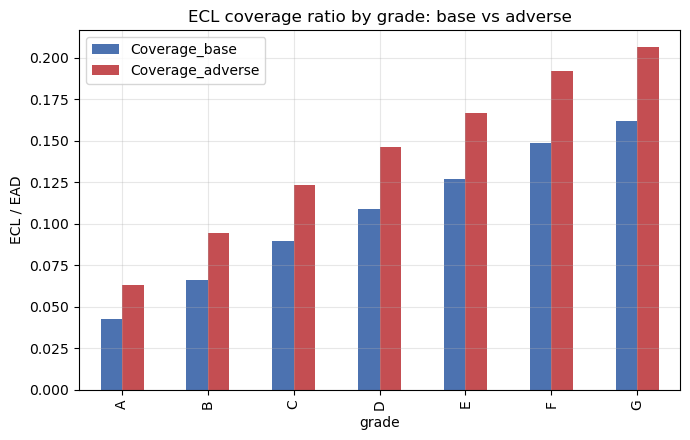

In [38]:
g_b = summarise(base, "grade")[["grade", "EAD", "ECL"]].rename(columns={"ECL": "ECL_base"})
g_a = summarise(adverse, "grade")[["grade", "ECL"]].rename(columns={"ECL": "ECL_adverse"})
scen = g_b.merge(g_a, on="grade")
scen["Coverage_base"] = scen["ECL_base"] / scen["EAD"]
scen["Coverage_adverse"] = scen["ECL_adverse"] / scen["EAD"]
scen["Uplift"] = scen["ECL_adverse"] / scen["ECL_base"] - 1
print(f"Adverse = PD odds x{ADV_ODDS_MULT}, LGD x{ADV_LGD_MULT}")
print(scen.to_string(index=False))

sc_plot = scen[scen["grade"] != "Total"].set_index("grade")[["Coverage_base", "Coverage_adverse"]]
ax = sc_plot.plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_title("ECL coverage ratio by grade: base vs adverse"); ax.set_ylabel("ECL / EAD")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_ecl_coverage_scenarios.png", dpi=150)
plt.show()

## 12. Excel summary

In [39]:
try:
    import openpyxl  # noqa: F401
except ImportError:
    import importlib, subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    importlib.invalidate_caches()
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

readme_df = pd.DataFrame({"Item": ["Purpose", "Scope", "Data", "Default", "PD", "LGD", "EAD", "ECL", "Stages", "Scenarios", "Caveat"],
    "Description": [
        "Simplified IFRS 9 ECL illustration on LendingClub loans",
        "Educational / portfolio project. NOT a production model.",
        "LendingClub accepted loans (Kaggle); closed loans for modelling, in-progress loans for ECL",
        "Charged Off/Default = 1, Fully Paid = 0; in-progress loans excluded from training",
        "WoE logistic regression scorecard (challenger: gradient boosting), out-of-time validated",
        "Exposure-weighted 1 - recoveries/EAD on defaulted loans, by grade",
        "Outstanding principal (out_prncp); at default = funded_amnt - total_rec_prncp",
        "PD x LGD x EAD with mid-horizon discounting at loan interest rate",
        "S1 12m PD; S2 lifetime PD (grace / 16-30 late); S3 PD=100% (31-120 late)",
        f"Adverse = PD odds x{ADV_ODDS_MULT}, LGD x{ADV_LGD_MULT}",
        "No macro-economic forward-looking model, no SICR on PD, constant-hazard term structure"]})

sheets = {
    "README": readme_df,
    "ECL_by_grade": ecl_grade,
    "ECL_by_stage": ecl_stage,
    "Scenarios": scen,
    "LGD_by_grade": lgd_by_grade,
    "Model_comparison": disc.reset_index().rename(columns={"index": "model"}),
    "Calibration": cal.reset_index().rename(columns={"index": "model"}),
    "Deciles_Scorecard": dec_sc,
    "Deciles_GBM": dec_gbm,
    "PSI": psi_df.sort_values("PSI", ascending=False),
    "Scorecard": scorecard_table,
}
FORMULAS = {"ECL_by_grade": {"Coverage": "={ECL}{r}/{EAD}{r}"},
            "ECL_by_stage": {"Coverage": "={ECL}{r}/{EAD}{r}"},
            "Scenarios": {"Coverage_base": "={ECL_base}{r}/{EAD}{r}",
                          "Coverage_adverse": "={ECL_adverse}{r}/{EAD}{r}",
                          "Uplift": "={ECL_adverse}{r}/{ECL_base}{r}-1"}}
PCT_KEYS = ("pd", "lgd", "coverage", "share", "rate", "uplift", "pct", "obs_dr")

xlsx_path = OUT_DIR / "ecl_summary.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as xw:
    for name, df_ in sheets.items():
        df_.to_excel(xw, sheet_name=name, index=False)
    for ws in xw.book.worksheets:
        name = ws.title
        headers = [c.value for c in ws[1]]
        letters = {h: get_column_letter(i + 1) for i, h in enumerate(headers)}
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill("solid", fgColor="1F4E78")
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for h, tmpl in FORMULAS.get(name, {}).items():
            if h in letters:
                for r in range(2, ws.max_row + 1):
                    ws[f"{letters[h]}{r}"] = tmpl.format(r=r, **letters)
        for i, h in enumerate(headers, start=1):
            col = get_column_letter(i)
            ws.column_dimensions[col].width = 70 if name == "README" and h == "Description" else max(12, min(40, len(str(h)) + 4))
            is_pct = any(k in str(h).lower() for k in PCT_KEYS) and name != "Scorecard"
            for r in range(2, ws.max_row + 1):
                c = ws[f"{col}{r}"]
                if isinstance(c.value, str) and c.value.startswith("="):
                    c.number_format = "0.00%"
                elif isinstance(c.value, float):
                    c.number_format = "0.00%" if is_pct else "#,##0.0000" if abs(c.value) < 10 else "#,##0"
                elif isinstance(c.value, int):
                    c.number_format = "#,##0"
        ws.freeze_panes = "A2"
        if name in FORMULAS:
            for c in ws[ws.max_row]:
                c.font = Font(bold=True)
print("Saved", xlsx_path)

Saved outputs\ecl_summary.xlsx


## 13. Documentation (README + model document, auto-filled with your results)

In [40]:
t = disc
tot_ead, tot_ecl = base["out_prncp"].sum(), base["ecl"].sum()
adv_ecl = adverse["ecl"].sum()

readme = f"""# Consumer Credit Risk: PD, LGD and Simplified IFRS 9 ECL (LendingClub)

> **Simplified IFRS 9 illustration, not a production model.**

## Overview
End-to-end credit risk project: out-of-time PD model (WoE scorecard vs gradient boosting), validation
(discrimination, calibration, stability), LGD and EAD from defaulted loans, and a Stage 1/2/3 ECL summary by grade
with a base vs adverse sensitivity.

## Key results
| Metric | Scorecard (OOT) | GBM (OOT) |
|---|---|---|
| AUC | {t.loc['Scorecard (OOT test)', 'AUC']:.3f} | {t.loc['GBM (OOT test)', 'AUC']:.3f} |
| Gini | {t.loc['Scorecard (OOT test)', 'Gini']:.3f} | {t.loc['GBM (OOT test)', 'Gini']:.3f} |
| KS | {t.loc['Scorecard (OOT test)', 'KS']:.3f} | {t.loc['GBM (OOT test)', 'KS']:.3f} |

* Chosen primary model: **{CHOICE}**. {reason}
* Portfolio ECL (base): {tot_ecl:,.0f} on EAD {tot_ead:,.0f} (coverage {tot_ecl / tot_ead:.2%}); adverse: {adv_ecl:,.0f} ({adv_ecl / tot_ecl - 1:+.1%}).
* Exposure-weighted LGD: {lgd_overall:.1%}.

## Repo structure
```
data/            # raw Kaggle file (not committed)
notebooks/       # lendingclub_ecl.ipynb
outputs/         # ecl_summary.xlsx, figures/
docs/            # MODEL_DOCUMENT.md
README.md
```

## How to run
1. Download the LendingClub CSV from Kaggle and set `DATA_PATH` in the config cell.
2. `pip install pandas numpy scikit-learn scipy matplotlib openpyxl`
3. Run the notebook top to bottom. Outputs are written to `outputs/`.

## Limitations
See `docs/MODEL_DOCUMENT.md`.
"""
(OUT_DIR / "README.md").write_text(readme)

model_doc = f"""# Model Document: Simplified IFRS 9 PD / LGD / EAD / ECL (LendingClub)

## 1. Purpose
Illustrate how a PD model feeds an IFRS 9-style Expected Credit Loss estimate for an unsecured consumer
loan portfolio. Educational scope only; not for provisioning or decision-making.

## 2. Data
* LendingClub accepted loans. Modelling sample = closed loans (Fully Paid vs Charged Off/Default); in-progress loans excluded.
* Train: issued up to {TRAIN_END} ({len(train):,} loans, default rate {train.y.mean():.2%}).
  Out-of-time test: {TEST_START} to {TEST_END} ({len(test):,} loans, default rate {test.y.mean():.2%}).
* Features: application-time only (loan terms, income, DTI, FICO, credit history, utilisation, etc.).
  LendingClub grade / interest rate are excluded from the PD model (they are the lender's own model output) and used only for reporting.

## 3. Methodology
* **PD**: WoE-binned logistic regression scorecard ({len(selected)} features, IV {IV_MIN}-{IV_MAX}, |corr| < {CORR_MAX}).
  Challenger: histogram gradient boosting on all features. Scorecard scaling: {BASE_SCORE} points at {BASE_ODDS}:1 odds, PDO {PDO}.
* **Variable checks**: {("removed after the coefficient-sign / score-spread checks: " + ", ".join(f"{c} ({why})" for c, why in dropped)) if dropped else "no variables needed removal in the coefficient-sign and score-spread checks"} (rules: negative coefficient on WoE; at least {MIN_POINT_SPREAD} points of score spread).
* **Recalibration**: scorecard intercept shifted by {shift:+.3f} to match the OOT default rate (flag `RECALIBRATE_TO_TEST`).
* **LGD**: 1 - net recoveries / EAD at default, exposure-weighted by grade (overall {lgd_overall:.1%}).
* **EAD**: outstanding principal (`out_prncp`) on the live book; at default approximated as funded amount - principal repaid.
* **ECL**: PD x LGD x EAD, mid-horizon discounted at the loan interest rate.
  Stage 1 = 12-month PD; Stage 2 (grace / 16-30 days late) = lifetime PD; Stage 3 (31-120 days late) = PD 100%.
  Term structure via constant hazard: PD_h = 1 - (1 - PD_life)^(h/term).
* **Scenarios**: adverse = PD odds x{ADV_ODDS_MULT}, LGD x{ADV_LGD_MULT}.

## 4. Validation results (out-of-time)
{t.round(4).to_string()}

Calibration:
{cal.round(4).to_string()}

Stability: score PSI = {psi_df.loc[psi_df.variable == 'SCORE (scorecard)', 'PSI'].iloc[0]:.3f}
({psi_df.loc[psi_df.variable == 'SCORE (scorecard)', 'flag'].iloc[0]}).

## 5. Model choice
{CHOICE}. {reason}

## 6. Results
Portfolio base ECL {tot_ecl:,.0f} / EAD {tot_ead:,.0f} = {tot_ecl / tot_ead:.2%}. Adverse ECL {adv_ecl:,.0f}.
Details by grade and stage in `outputs/ecl_summary.xlsx`.

## 7. Limitations
* Right-censoring: recent vintages show lower default rates because bad loans have not matured yet.
* Population drift: LendingClub underwriting changed over time; PDs are recalibrated on one window only.
* Stage allocation uses delinquency status only; no PD-based SICR test, no forward-looking macro scenarios or probability-weighting.
* Constant-hazard term structure; no prepayment modelling; discounting uses the contract rate as a proxy for EIR.
* LGD is a grade-level average of cash recoveries without discounting or recovery-timing curves.
* EAD ignores undrawn commitments (term loans only).
* Only one test window; no stress test beyond a simple multiplier. Fairness / bias review not performed.
"""
(OUT_DIR / "MODEL_DOCUMENT.md").write_text(model_doc)
print("Wrote:", [p.name for p in OUT_DIR.iterdir()])
print("Done. Figures in", FIG_DIR)

Wrote: ['ecl_summary.xlsx', 'figures', 'MODEL_DOCUMENT.md', 'README.md']
Done. Figures in outputs\figures
